# SRNet-Style CNN on Reshuffled Midjourney vs Real Splits

Audience:
- ENSF 617 students who want a simpler notebook than the other project notebooks.
- Readers who know basic Python, classes, loops, and tensors, but are still learning deep learning workflows.

Prerequisites:
- Basic PyTorch ideas: tensors, datasets, dataloaders, models, and training loops.
- Basic image ideas: grayscale, blur, cropping, and labels.

Learning goals:
- Read labels from the manifest files in `ensf617/output/metadata`.
- Keep only `real` images and Midjourney images, where Midjourney is `label_b = 5`.
- Combine all `real` and Midjourney rows from the original train, validation, and test manifests.
- Build a fresh stratified `70 / 15 / 15` split with a fixed random seed.
- Build a dataset that turns each image into a center-cropped residual autocorrelation map.
- Train an SRNet-style CNN from scratch on that representation.
- Evaluate the trained model on validation and test data.

This notebook is intentionally written in a very direct style. It avoids clever abstractions so the code is easier to follow cell by cell.

## Outline

1. Import the libraries we need.
2. Point to the dataset and manifest files.
3. Read, combine, and reshuffle the manifest rows.
4. Build a simple dataset that computes center-cropped residual autocorrelation maps.
5. Build a small SRNet-style model.
6. Train the model.
7. Evaluate on validation and test data.
8. Look at a few extensions you could try next.

In [27]:
import copy
import csv
import hashlib
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.transforms import functional as TF

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

Device: mps


## Step 1 - Find the data

Our project data is not stored inside the git repository. Instead, it lives in the sibling folder `ensf617/output`.

This cell looks for that folder first. If it is not there, it falls back to `output` inside the project. That fallback is helpful if you ever copy the notebook somewhere else.

In [ ]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'requirements.txt').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT.parent / 'ensf617' / 'output'
if not DATA_ROOT.exists():
    DATA_ROOT = PROJECT_ROOT / 'output'

TRAIN_MANIFEST = DATA_ROOT / 'metadata' / 'train_manifest.csv'
VAL_MANIFEST = DATA_ROOT / 'metadata' / 'validation_manifest.csv'
TEST_MANIFEST = DATA_ROOT / 'metadata' / 'test_manifest.csv'

model_label_b = 3

MODEL_DIR = PROJECT_ROOT / 'saved_models'
MODEL_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH = MODEL_DIR / 'srnet_reshuffled_split_autocorr_midjourney_best.pt'

split_seed = 617
train_fraction = 0.70
val_fraction = 0.15
test_fraction = 0.15
crop_before_autocorr = 256
train_resize_short_side = 320
eval_resize_short_side = 256
flip_probability = 0.5
final_map_size = 224
gaussian_kernel_size = 5
gaussian_sigma = 1.0
batch_size = 32
learning_rate = 1e-3
weight_decay = 1e-4
epochs = 5
num_workers = 0

print('Project root:', PROJECT_ROOT)
print('Data root:', DATA_ROOT)
print('Train manifest:', TRAIN_MANIFEST)
print('Validation manifest:', VAL_MANIFEST)
print('Test manifest:', TEST_MANIFEST)
print('Best model path:', BEST_MODEL_PATH)
print('Split seed:', split_seed)
print('Split fractions:', train_fraction, val_fraction, test_fraction)

Project root: /Users/williamwatson/meng_winter_courses/codex/ENSF617-Project
Data root: /Users/williamwatson/meng_winter_courses/codex/ensf617/output
Train manifest: /Users/williamwatson/meng_winter_courses/codex/ensf617/output/metadata/train_manifest.csv
Validation manifest: /Users/williamwatson/meng_winter_courses/codex/ensf617/output/metadata/validation_manifest.csv
Test manifest: /Users/williamwatson/meng_winter_courses/codex/ensf617/output/metadata/test_manifest.csv
Best model path: /Users/williamwatson/meng_winter_courses/codex/ENSF617-Project/saved_models/srnet_reshuffled_split_autocorr_midjourney_best.pt
Split seed: 617
Split fractions: 0.7 0.15 0.15


## Step 2 - Read, combine, and reshuffle the manifest files

The manifest files tell us:
- which image to open
- what the label is
- what caption created that image

For this notebook, we do **not** use every AI model.

We keep these rows only:
- all `real` images
- only Midjourney images from the AI side

Then we ignore the original split boundaries.

We combine the filtered rows from all three manifests, remove exact duplicate image files by hash, and then make a fresh stratified split:
- `70%` train
- `15%` validation
- `15%` test

We do the new split separately for the `real` rows and the Midjourney rows so the class balance stays sensible.

We will use `label_a` as the binary class label:
- `0` means `real`
- `1` means `ai_generated`

We will use `label_b` only for filtering:
- `label_b = 5` means Midjourney

In [29]:
with TRAIN_MANIFEST.open(newline='', encoding='utf-8') as handle:
    original_train_rows = list(csv.DictReader(handle))

with VAL_MANIFEST.open(newline='', encoding='utf-8') as handle:
    original_val_rows = list(csv.DictReader(handle))

with TEST_MANIFEST.open(newline='', encoding='utf-8') as handle:
    original_test_rows = list(csv.DictReader(handle))

original_train_rows = [row for row in original_train_rows if int(row['label_a']) == 0 or int(row['label_b']) == model_label_b]
original_val_rows = [row for row in original_val_rows if int(row['label_a']) == 0 or int(row['label_b']) == model_label_b]
original_test_rows = [row for row in original_test_rows if int(row['label_a']) == 0 or int(row['label_b']) == model_label_b]

print('Original filtered counts:')
print('Train real / midjourney:', sum(int(row['label_a']) == 0 for row in original_train_rows), sum(int(row['label_a']) == 1 for row in original_train_rows))
print('Validation real / midjourney:', sum(int(row['label_a']) == 0 for row in original_val_rows), sum(int(row['label_a']) == 1 for row in original_val_rows))
print('Test real / midjourney:', sum(int(row['label_a']) == 0 for row in original_test_rows), sum(int(row['label_a']) == 1 for row in original_test_rows))

all_rows = original_train_rows + original_val_rows + original_test_rows
print('Combined filtered rows before deduplication:', len(all_rows))

all_rows[0]

Original filtered counts:
Train real / midjourney: 3817 3817
Validation real / midjourney: 1500 1500
Test real / midjourney: 1594 1594
Combined filtered rows before deduplication: 13822


{'row_index': '0',
 'image_path': 'train/train_000000.png',
 'label_a': '0',
 'label_a_name': 'real',
 'label_b': '0',
 'caption': 'Two tall giraffe standing next to each other on a  field.'}

## Step 3 - Prepare the data as plain Python lists

This cell does the reshuffle and preprocessing directly in simple loops.

There is no custom dataset class here. Instead, we build three plain Python lists:
- `train_dataset`
- `val_dataset`
- `test_dataset`

First, we remove duplicate files across the whole combined pool.

Then we split the data again from scratch:
- `70%` train
- `15%` validation
- `15%` test

We split the `real` rows and Midjourney rows separately, then combine them again inside each new split.

After that, each list stores pairs of `(autocorrelation_map, label)`.

For every image, we do these steps:
1. Open the image.
2. Resize it only if it is too small.
3. Take a crop from the image.
4. Convert it to grayscale.
5. Compute a simple residual by subtracting a blurred version.
6. Compute the 2D autocorrelation of that residual.
7. Center crop the autocorrelation map to `224 x 224`.
8. Normalize the map so training is more stable.

Notice that the images still live in their original folders even after we make the new split. The notebook reads the file path stored in the manifest row, so a new training row might still point to an old `validation/...` file on disk.

Training uses random crop and random horizontal flip before the residual/autocorrelation step.
Validation and test use center crop only.

In [30]:
deduped_rows = []
seen_hashes = set()
duplicates_removed = 0

for row in all_rows:
    image_path = DATA_ROOT / row['image_path']

    if not image_path.exists():
        image_name = Path(row['image_path']).name

        for folder_name in ['train', 'validation', 'test']:
            candidate = DATA_ROOT / folder_name / image_name

            if candidate.exists():
                image_path = candidate
                break

    with image_path.open('rb') as handle:
        image_hash = hashlib.md5(handle.read()).hexdigest()

    if image_hash in seen_hashes:
        duplicates_removed += 1
        continue

    seen_hashes.add(image_hash)
    deduped_rows.append(row)

print('Rows after deduplication:', len(deduped_rows), '| duplicates removed:', duplicates_removed)

real_rows = [row for row in deduped_rows if int(row['label_a']) == 0]
midjourney_rows = [row for row in deduped_rows if int(row['label_a']) == 1]

split_random = random.Random(split_seed)
split_random.shuffle(real_rows)
split_random.shuffle(midjourney_rows)

real_train_count = int(len(real_rows) * train_fraction)
real_val_count = int(len(real_rows) * val_fraction)
midjourney_train_count = int(len(midjourney_rows) * train_fraction)
midjourney_val_count = int(len(midjourney_rows) * val_fraction)

train_rows = real_rows[:real_train_count] + midjourney_rows[:midjourney_train_count]
val_rows = real_rows[real_train_count:real_train_count + real_val_count] + midjourney_rows[midjourney_train_count:midjourney_train_count + midjourney_val_count]
test_rows = real_rows[real_train_count + real_val_count:] + midjourney_rows[midjourney_train_count + midjourney_val_count:]

split_random.shuffle(train_rows)
split_random.shuffle(val_rows)
split_random.shuffle(test_rows)

print('New train real / midjourney:', sum(int(row['label_a']) == 0 for row in train_rows), sum(int(row['label_a']) == 1 for row in train_rows))
print('New validation real / midjourney:', sum(int(row['label_a']) == 0 for row in val_rows), sum(int(row['label_a']) == 1 for row in val_rows))
print('New test real / midjourney:', sum(int(row['label_a']) == 0 for row in test_rows), sum(int(row['label_a']) == 1 for row in test_rows))


def get_image_path(row):
    image_path = DATA_ROOT / row['image_path']

    if image_path.exists():
        return image_path

    image_name = Path(row['image_path']).name

    for folder_name in ['train', 'validation', 'test']:
        candidate = DATA_ROOT / folder_name / image_name

        if candidate.exists():
            return candidate

    return image_path


def build_dataset(rows, use_random_crop, use_random_flip):
    processed_rows = []

    for row in rows:
        image_path = get_image_path(row)

        image = Image.open(image_path).convert('L')

        width, height = image.size
        short_side = min(width, height)

        if use_random_crop:
            resize_target = train_resize_short_side
        else:
            resize_target = eval_resize_short_side

        if short_side < resize_target:
            scale = resize_target / short_side
            new_width = round(width * scale)
            new_height = round(height * scale)
            image = image.resize((new_width, new_height))

        if use_random_crop:
            max_top = image.height - crop_before_autocorr
            max_left = image.width - crop_before_autocorr

            if max_top > 0:
                top = random.randint(0, max_top)
            else:
                top = 0

            if max_left > 0:
                left = random.randint(0, max_left)
            else:
                left = 0

            image = TF.crop(image, top, left, crop_before_autocorr, crop_before_autocorr)

            if use_random_flip and random.random() < flip_probability:
                image = TF.hflip(image)
        else:
            image = TF.center_crop(image, [crop_before_autocorr, crop_before_autocorr])

        image = TF.to_tensor(image)

        blurred = TF.gaussian_blur(image, kernel_size=gaussian_kernel_size, sigma=gaussian_sigma)
        residual = image - blurred

        spectrum = torch.fft.fft2(residual)
        autocorr = torch.fft.ifft2(spectrum * torch.conj(spectrum)).real
        autocorr = torch.fft.fftshift(autocorr, dim=(-2, -1))
        autocorr = TF.center_crop(autocorr, [final_map_size, final_map_size])

        autocorr = autocorr - autocorr.mean()
        autocorr = autocorr / (autocorr.std() + 1e-6)

        label = int(row['label_a'])
        processed_rows.append((autocorr, label))

    return processed_rows


train_dataset = build_dataset(train_rows, use_random_crop=True, use_random_flip=True)
val_dataset = build_dataset(val_rows, use_random_crop=False, use_random_flip=False)
test_dataset = build_dataset(test_rows, use_random_crop=False, use_random_flip=False)

print('train dataset length:', len(train_dataset))
print('validation dataset length:', len(val_dataset))
print('test dataset length:', len(test_dataset))

Rows after deduplication: 13822 | duplicates removed: 0
New train real / midjourney: 4837 4837
New validation real / midjourney: 1036 1036
New test real / midjourney: 1038 1038
train dataset length: 9674
validation dataset length: 2072
test dataset length: 2076


## Step 4 - Build an SRNet-style model

This is **not** an exact copy of the original SRNet paper.

Instead, it is a small model inspired by the same general ideas:
- single-channel input
- small `3 x 3` convolutions
- residual connections
- no giant ImageNet-style stem
- no aggressive downsampling at the very start

That makes it a better fit for forensic-style inputs than a standard image classifier with a large first convolution.

In [31]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        else:
            self.shortcut = None

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = torch.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.shortcut is not None:
            identity = self.shortcut(identity)

        out = out + identity
        out = torch.relu(out)
        return out


class SimpleSRNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.block1 = ResidualBlock(32, 32, stride=1)
        self.block2 = ResidualBlock(32, 64, stride=2)
        self.block3 = ResidualBlock(64, 64, stride=1)
        self.block4 = ResidualBlock(64, 128, stride=2)
        self.block5 = ResidualBlock(128, 128, stride=1)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, 2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)

        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


model = SimpleSRNet().to(device)
print(model)

SimpleSRNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): ResidualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2))
  )
  (block3): Re

## Step 5 - Create dataloaders and inspect one sample

Before training, it is always a good idea to check that:
- the dataloaders run
- the tensor shape looks correct
- the labels look correct
- the preprocessing output looks reasonable

Even though these datasets are just plain Python lists, `DataLoader` can still batch them for us.

Batch image shape: torch.Size([32, 1, 224, 224])
Batch label shape: torch.Size([32])
First label: 1 ai_generated


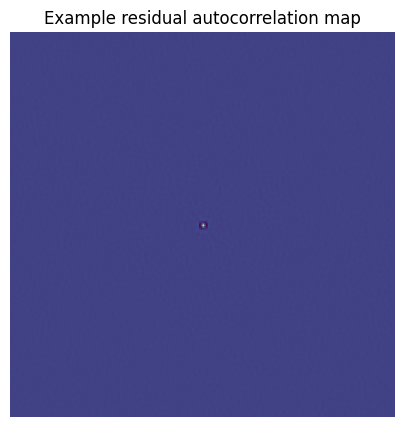

In [32]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)


class_names = ['real', 'ai_generated']

sample_images, sample_labels = next(iter(train_loader))

print('Batch image shape:', sample_images.shape)
print('Batch label shape:', sample_labels.shape)
print('First label:', sample_labels[0].item(), class_names[sample_labels[0].item()])

sample_map = sample_images[0].squeeze(0)
sample_map = sample_map - sample_map.min()
sample_map = sample_map / (sample_map.max() + 1e-6)

plt.figure(figsize=(5, 5))
plt.imshow(sample_map.numpy(), cmap='viridis')
plt.title('Example residual autocorrelation map')
plt.axis('off')
plt.show()

## Step 6 - Train the model

This training loop is written out directly instead of being hidden inside helper functions.

That makes it longer, but it also makes it easier to see exactly what happens in each epoch.

At the start of every epoch, we rebuild the training data from the reshuffled training rows with new random crops and flips, shuffle the batches, and save the model whenever validation accuracy improves.

In [33]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

best_val_accuracy = 0.0
best_state = copy.deepcopy(model.state_dict())
history = []

for epoch in range(epochs):
    train_dataset = build_dataset(train_rows, use_random_crop=True, use_random_flip=True)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    print('Epoch', epoch + 1, '| rebuilt training data with new random crops and flips')

    model.train()
    train_loss_total = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * labels.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_total / train_total
    train_accuracy = train_correct / train_total

    model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss_total += loss.item() * labels.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_total / val_total
    val_accuracy = val_correct / val_total

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_state = copy.deepcopy(model.state_dict())
        torch.save({
            'epoch': epoch + 1,
            'val_accuracy': val_accuracy,
            'model_state_dict': best_state,
        }, BEST_MODEL_PATH)
        print('Saved new best model at epoch', epoch + 1, 'with validation accuracy', round(val_accuracy, 4))
        print('Saved to:', BEST_MODEL_PATH)

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'val_loss': val_loss,
        'val_accuracy': val_accuracy,
    })

    print(
        'Epoch', epoch + 1,
        '| train loss =', round(train_loss, 4),
        '| train acc =', round(train_accuracy, 4),
        '| val loss =', round(val_loss, 4),
        '| val acc =', round(val_accuracy, 4)
    )

model.load_state_dict(best_state)
print('Best validation accuracy:', round(best_val_accuracy, 4))
print('Final best model path:', BEST_MODEL_PATH)

Epoch 1 | rebuilt training data with new random crops and flips
Saved new best model at epoch 1 with validation accuracy 0.7206
Saved to: /Users/williamwatson/meng_winter_courses/codex/ENSF617-Project/saved_models/srnet_reshuffled_split_autocorr_midjourney_best.pt
Epoch 1 | train loss = 0.5693 | train acc = 0.7249 | val loss = 0.5907 | val acc = 0.7206
Epoch 2 | rebuilt training data with new random crops and flips
Saved new best model at epoch 2 with validation accuracy 0.7582
Saved to: /Users/williamwatson/meng_winter_courses/codex/ENSF617-Project/saved_models/srnet_reshuffled_split_autocorr_midjourney_best.pt
Epoch 2 | train loss = 0.5367 | train acc = 0.7423 | val loss = 0.5301 | val acc = 0.7582
Epoch 3 | rebuilt training data with new random crops and flips
Epoch 3 | train loss = 0.5279 | train acc = 0.7542 | val loss = 0.5855 | val acc = 0.6998
Epoch 4 | rebuilt training data with new random crops and flips
Saved new best model at epoch 4 with validation accuracy 0.7741
Saved to

KeyboardInterrupt: 

## Step 7 - Plot the training history

A quick plot helps us see whether training is improving and whether validation performance is following along.

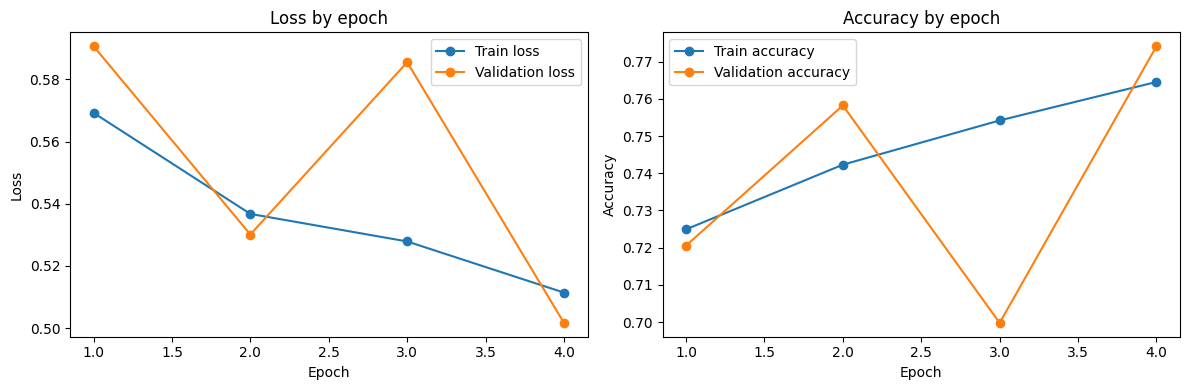

In [34]:
epoch_numbers = [row['epoch'] for row in history]
train_losses = [row['train_loss'] for row in history]
val_losses = [row['val_loss'] for row in history]
train_accuracies = [row['train_accuracy'] for row in history]
val_accuracies = [row['val_accuracy'] for row in history]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epoch_numbers, train_losses, marker='o', label='Train loss')
plt.plot(epoch_numbers, val_losses, marker='o', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss by epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_numbers, train_accuracies, marker='o', label='Train accuracy')
plt.plot(epoch_numbers, val_accuracies, marker='o', label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy by epoch')
plt.legend()

plt.tight_layout()
plt.show()

## Step 8 - Evaluate on the test set

We now evaluate the best validation checkpoint on the test set.

The confusion matrix is arranged like this:
- rows are the true labels
- columns are the predicted labels

In [35]:
model.eval()
test_loss_total = 0.0
test_correct = 0
test_total = 0
confusion = torch.zeros(2, 2, dtype=torch.int64)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        predictions = outputs.argmax(dim=1)

        test_loss_total += loss.item() * labels.size(0)
        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

        for true_label, predicted_label in zip(labels.cpu(), predictions.cpu()):
            confusion[true_label, predicted_label] += 1

test_loss = test_loss_total / test_total
test_accuracy = test_correct / test_total

print('Test loss:', round(test_loss, 4))
print('Test accuracy:', round(test_accuracy, 4))
print('\nConfusion matrix:')
print(confusion)

real_recall = confusion[0, 0].item() / confusion[0].sum().item()
ai_recall = confusion[1, 1].item() / confusion[1].sum().item()

print('\nReal recall:', round(real_recall, 4))
print('AI recall:', round(ai_recall, 4))

Test loss: 0.7367
Test accuracy: 0.6339

Confusion matrix:
tensor([[946,  92],
        [668, 370]])

Real recall: 0.9114
AI recall: 0.3565


## Exercises, pitfalls, and next steps

Exercises:
- Change `split_seed` and see how much the new random split changes the result.
- Change `crop_before_autocorr` from `256` to `320` and compare the results.
- Change `gaussian_kernel_size` from `5` to `7` and see how the residual changes.
- Replace the SRNet-style model with a smaller or larger version and compare validation accuracy.

Common pitfall:
- If the notebook cannot find the images, check whether your manifest paths are flat (`train/example.png`) or nested (`train/real/example.png`). This notebook tries both, but the data folder still needs to exist.

Possible extension:
- Try the exact same notebook with raw residual maps instead of autocorrelation maps. That gives you a clean ablation between `residual` and `residual autocorrelation`.

In [ ]:
# Exercise scaffold:
# Pick one change, run the notebook again, and write down what changed.

my_change = 'example: split_seed = 123'
my_prediction = 'example: a different reshuffled split might lower or raise validation accuracy'
my_result = 'fill this in after you run the notebook'

print('My change:', my_change)
print('My prediction:', my_prediction)
print('My result:', my_result)

My change: example: split_seed = 123
My prediction: example: a different reshuffled split might lower or raise validation accuracy
My result: fill this in after you run the notebook
